# Thesis Figures
Generation of publication-quality figures for the thesis.
Loads pre-processed windowed signals and generates segmentation figures.

## 1. Imports and configuration

In [1]:
import pickle
import logging
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

from src import (
    plot_station_windows,
    plot_station_windows_multitype,
    plot_multiple_stations,
    convert_signals_to_dict,
    add_time_columns
)

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

In [2]:
# ── Project paths ─────────────────────────────────────────────────────────────
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent

THESIS_FIGURES_DIR = PROJECT_ROOT / 'figures' / 'thesis'
THESIS_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ── Signal configuration ──────────────────────────────────────────────────────
SIGNAL_TYPES = ['acceleration', 'velocity', 'displacement']

SIGNAL_UNITS = {
    'acceleration': 'cm/s²',
    'velocity':     'cm/s',
    'displacement': 'cm',
}

SIGNAL_COLUMNS = {
    'acceleration': 'acceleration',
    'velocity':     'velocity',
    'displacement': 'displacement',
}

# ── Helper: build processed data paths ───────────────────────────────────────
def get_ar_aic_windowed_path(event_id: str, signal_type: str, coda_method: str) -> Path:
    return (
        PROJECT_ROOT / 'data' / 'processed' / event_id
        / '03a_phase_identification_ar_pick' / signal_type
        / f'windowed_{signal_type}_{coda_method}_ar_pick.pkl'
    )

def get_phasenet_windowed_path(event_id: str, signal_type: str, phasenet_config: str, coda_method: str) -> Path:
    return (
        PROJECT_ROOT / 'data' / 'processed' / event_id
        / '03b_phase_identification_phasenet' / phasenet_config / signal_type
        / f'windowed_{signal_type}_{coda_method}_phasenet.pkl'
    )

def get_signals_path(event_id: str, signal_type: str) -> Path:
    return (
        PROJECT_ROOT / 'data' / 'processed' / event_id
        / '01b_signals' / signal_type
        / f'{signal_type[:3]}_preprocessed_scaling.parquet'
    )

def get_metadata_path(event_id: str, signal_type: str) -> Path:
    return (
        PROJECT_ROOT / 'data' / 'processed' / event_id
        / '01a_metadata' / signal_type
        / f'metadata_clean_{signal_type[:3]}.parquet'
    )

# ── Helper: load windowed signals ─────────────────────────────────────────────
def load_windowed(path: Path) -> dict:
    with open(path, 'rb') as f:
        return pickle.load(f)

# ── Helper: load signals dict for all three signal types ─────────────────────
from src import add_time_columns, convert_signals_to_dict, get_station_from_filename

def load_signals_dicts(event_id: str) -> dict:
    signals_dicts = {}
    df_meta = pd.read_parquet(get_metadata_path(event_id, 'acceleration'))
    for st in SIGNAL_TYPES:
        df = pd.read_parquet(get_signals_path(event_id, st))
        df = add_time_columns(
            df,
            df_meta,
            time_col='DATE_TIME_FIRST_SAMPLE',
            sampling_interval_col='SAMPLING_INTERVAL_S',
        )
        signals_dicts[st] = convert_signals_to_dict(
            df, signal_column=SIGNAL_COLUMNS[st]
        )
    return signals_dicts

# ── Helper: load windowed signals for all three signal types ──────────────────
def load_windowed_dicts_ar_aic(event_id: str, coda_method: str) -> dict:
    return {
        st: load_windowed(get_ar_aic_windowed_path(event_id, st, coda_method))
        for st in SIGNAL_TYPES
    }

def load_windowed_dicts_phasenet(event_id: str, phasenet_config: str, coda_method: str) -> dict:
    return {
        st: load_windowed(get_phasenet_windowed_path(event_id, st, phasenet_config, coda_method))
        for st in SIGNAL_TYPES
    }

In [3]:
mode='thesis'

## 2. INT-41004391 (Queyras, Mw 3.8)

In [4]:
EVENT_ID_QUEYRAS = 'INT-41004391'
STATION_QUEYRAS  = 'OGDI'
CODA_METHOD      = 'rautian'

FIGURES_QUEYRAS = THESIS_FIGURES_DIR / EVENT_ID_QUEYRAS / 'segmentation'
FIGURES_QUEYRAS.mkdir(parents=True, exist_ok=True)

# Load metadata and signals
df_meta_queyras = pd.read_parquet(
    get_metadata_path(EVENT_ID_QUEYRAS, 'acceleration')
)
signals_dicts_queyras = load_signals_dicts(EVENT_ID_QUEYRAS)
logger.info(f"Loaded signals for {EVENT_ID_QUEYRAS}")

Added relative time column (t=0 at first sample)
Sampling rate: 200.0 Hz (interval: 0.005 s)
Relative time range: 0.000 - 279.995 s

Added absolute time column
Absolute time range: 2024-12-09 10:40:26 to 2024-12-09 10:45:09.995000
Signal duration: min=30.00, median=240.00, max=280.00 s (66 files)
Converting 66 files to nested dictionary...
Signal column: 'acceleration'
Converted 66 files
Stations: 22
Components per station: {3}
Added relative time column (t=0 at first sample)
Sampling rate: 200.0 Hz (interval: 0.005 s)
Relative time range: 0.000 - 279.995 s

Added absolute time column
Absolute time range: NaT to NaT
Signal duration: min=30.00, median=240.00, max=280.00 s (66 files)
Converting 66 files to nested dictionary...
Signal column: 'velocity'
Converted 66 files
Stations: 22
Components per station: {3}
Added relative time column (t=0 at first sample)
Sampling rate: 200.0 Hz (interval: 0.005 s)
Relative time range: 0.000 - 279.995 s

Added absolute time column
Absolute time range

INFO:__main__:Loaded signals for INT-41004391


Converted 66 files
Stations: 22
Components per station: {3}


### 2.1 AR-AIC segmentation

INFO:__main__:Loaded AR-AIC windowed signals for Queyras


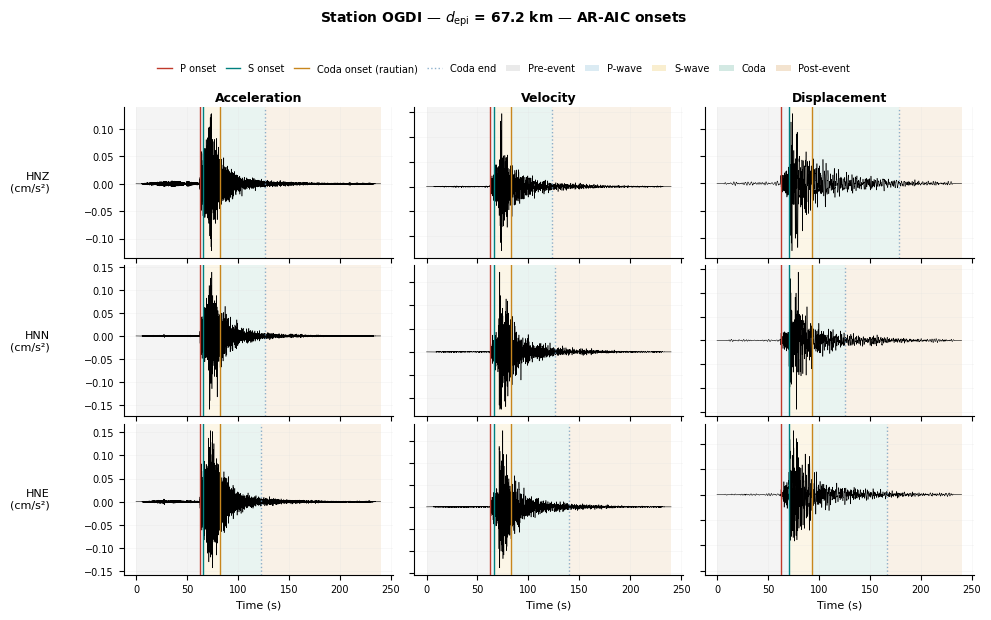

In [ ]:
windowed_ar_aic_queyras = load_windowed_dicts_ar_aic(EVENT_ID_QUEYRAS, CODA_METHOD)
logger.info("Loaded AR-AIC windowed signals for Queyras")
plt.close('all')
fig = plot_station_windows_multitype(
    station=STATION_QUEYRAS,
    signals_dicts=signals_dicts_queyras,
    windowed_signals_dicts=windowed_ar_aic_queyras,
    signal_units=SIGNAL_UNITS,
    df_onsets=df_meta_queyras,
    coda_method=CODA_METHOD,
    title_suffix='AR-AIC onsets',
    output_path=FIGURES_QUEYRAS / f'{STATION_QUEYRAS}_ar_aic_{CODA_METHOD}',
    mode=mode,
)
plt.show()

In [9]:
for st in ['acceleration', 'velocity', 'displacement']:
    print(st, SIGNAL_UNITS[st])

acceleration cm/s²
velocity cm/s
displacement cm


### 2.3 PhaseNet segmentation — threshold configuration

INFO:__main__:Loaded PhaseNet threshold windowed signals for Queyras


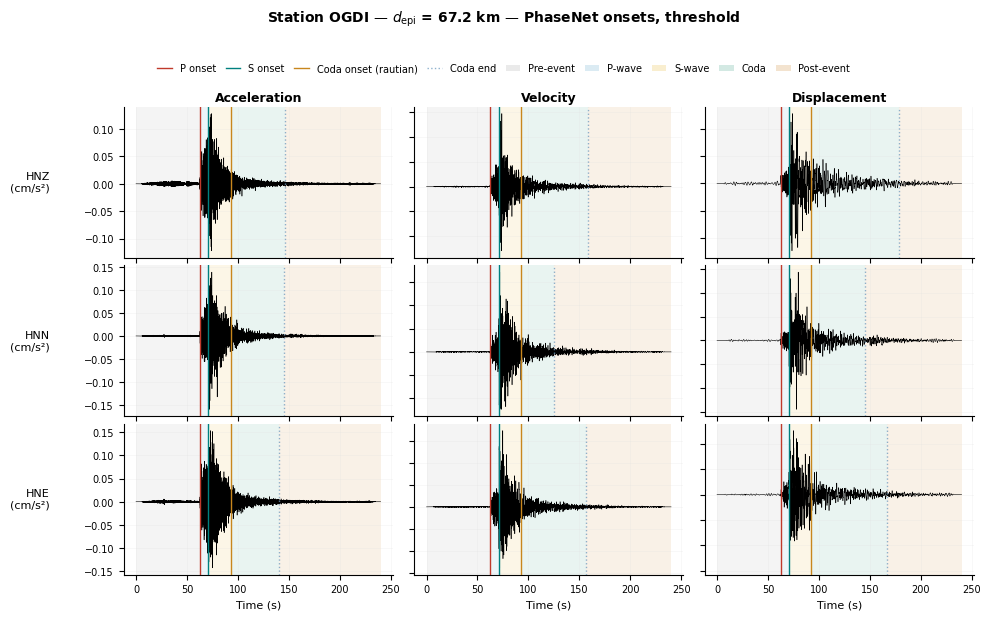

In [ ]:
PHASENET_CONFIG_THRESH = 'thresh_30'

windowed_phasenet_thresh_queyras = load_windowed_dicts_phasenet(
    EVENT_ID_QUEYRAS, PHASENET_CONFIG_THRESH, CODA_METHOD
)
logger.info("Loaded PhaseNet threshold windowed signals for Queyras")
plt.close('all')
fig = plot_station_windows_multitype(
    station=STATION_QUEYRAS,
    signals_dicts=signals_dicts_queyras,
    windowed_signals_dicts=windowed_phasenet_thresh_queyras,
    signal_units=SIGNAL_UNITS,
    df_onsets=df_meta_queyras,
    coda_method=CODA_METHOD,
    title_suffix='PhaseNet onsets, threshold',
    output_path=FIGURES_QUEYRAS / f'{STATION_QUEYRAS}_phasenet_thresh_{CODA_METHOD}',
    mode=mode,
)
plt.show()

## 3. IT-2009-0009 (L'Aquila, Mw 6.1)

In [7]:
EVENT_ID_LAQUILA = 'IT-2009-0009'
STATION_LAQUILA  = 'OGDI'  # update after station selection

FIGURES_LAQUILA = THESIS_FIGURES_DIR / EVENT_ID_LAQUILA / 'segmentation'
FIGURES_LAQUILA.mkdir(parents=True, exist_ok=True)

df_meta_laquila = pd.read_parquet(
    get_metadata_path(EVENT_ID_LAQUILA, 'acceleration')
)
signals_dicts_laquila = load_signals_dicts(EVENT_ID_LAQUILA)
logger.info(f"Loaded signals for {EVENT_ID_LAQUILA}")

Added relative time column (t=0 at first sample)
Sampling rate: 200.0 Hz (interval: 0.005 s)
Relative time range: 0.000 - 312.385 s

Added absolute time column
Absolute time range: 2009-04-06 01:31:52 to 2009-04-06 03:29:57.985000
Signal duration: min=39.99, median=100.00, max=312.38 s (192 files)
Converting 192 files to nested dictionary...
Signal column: 'acceleration'
Converted 192 files
Stations: 64
Components per station: {3}
Added relative time column (t=0 at first sample)
Sampling rate: 200.0 Hz (interval: 0.005 s)
Relative time range: 0.000 - 312.385 s

Added absolute time column
Absolute time range: NaT to NaT
Signal duration: min=39.99, median=100.00, max=312.38 s (192 files)
Converting 192 files to nested dictionary...
Signal column: 'velocity'
Converted 192 files
Stations: 64
Components per station: {3}
Added relative time column (t=0 at first sample)
Sampling rate: 200.0 Hz (interval: 0.005 s)
Relative time range: 0.000 - 312.385 s

Added absolute time column
Absolute time

INFO:__main__:Loaded signals for IT-2009-0009


Converted 192 files
Stations: 64
Components per station: {3}


### 3.1 AR-AIC segmentation

In [8]:
windowed_ar_aic_laquila = load_windowed_dicts_ar_aic(EVENT_ID_LAQUILA, CODA_METHOD)
logger.info("Loaded AR-AIC windowed signals for L'Aquila")

fig = plot_station_windows_multitype(
    station=STATION_LAQUILA,
    signals_dicts=signals_dicts_laquila,
    windowed_signals_dicts=windowed_ar_aic_laquila,
    signal_units=SIGNAL_UNITS,
    df_onsets=df_meta_laquila,
    coda_method=CODA_METHOD,
    title_suffix='AR-AIC onsets',
    output_path=FIGURES_LAQUILA / f'{STATION_LAQUILA}_ar_aic_{CODA_METHOD}',
    mode=mode,
)
plt.show()

INFO:__main__:Loaded AR-AIC windowed signals for L'Aquila


ValueError: Number of rows must be a positive integer, not 0

<Figure size 1000x650 with 0 Axes>

### 3.2 PhaseNet segmentation — no-filter configuration

In [ ]:
PHASENET_CONFIG_NOFILT = 'no_filter'
windowed_phasenet_nofilt_laquila = load_windowed_dicts_phasenet(
    EVENT_ID_LAQUILA, PHASENET_CONFIG_NOFILT, CODA_METHOD
)
logger.info("Loaded PhaseNet no-filter windowed signals for L'Aquila")

fig = plot_station_windows_multitype(
    station=STATION_LAQUILA,
    signals_dicts=signals_dicts_laquila,
    windowed_signals_dicts=windowed_phasenet_nofilt_laquila,
    signal_units=SIGNAL_UNITS,
    df_onsets=df_meta_laquila,
    coda_method=CODA_METHOD,
    title_suffix='PhaseNet onsets, no-filter',
    output_path=FIGURES_LAQUILA / f'{STATION_LAQUILA}_phasenet_nofilt_{CODA_METHOD}',
    mode=mode,
)
plt.show()